# RRT* (Rapidly-exploring Random Tree Star) Path Planning

### What This Script Does
This notebook builds a ground-up simulation of the RRT* path-planning algorithm. It sets up a 2D environment with a starting coordinate and a goal coordinate. When executed, it uses `matplotlib` and IPython's display tools to create a live, frame-by-frame animation of the algorithm searching the space, building its tree, optimizing its branches, and finally highlighting the most efficient path it found.

### How the RRT* Algorithm Works
Standard RRT grows a random web of lines until it stumbles into the goal, often resulting in highly inefficient, jagged paths. **RRT*** adds an optimization step ("rewiring") that constantly smooths and shortens the path as it explores.

Here is the loop it follows:
1. **Sample:** It picks a random `(x, y)` coordinate on the map.
2. **Nearest:** It scans its existing tree to find the node closest to that random point.
3. **Steer:** It grows a new branch from that closest node toward the random point (by a fixed `step_size`).
4. **Near Neighbors:** It draws a search radius around this newly created branch and finds all other existing nodes within that circle.
5. **Choose Best Parent:** Instead of blindly connecting the new branch to the node that spawned it, it calculates the total distance from the *start* point through all those neighbors. It connects to the neighbor that yields the lowest total distance.
6. **Rewire (The "Star"):** It looks at those neighbors again. If any of those neighbors could get a shorter path back to the start by routing *through* our new branch, the algorithm deletes their old connection and "rewires" them to the new branch. This continuously straightens the tree.

### Setup, Imports, and Node Data Structure
Here we import the math and visualization libraries. We also define the `Node` class, which is the fundamental building block of our tree. Each Node represents a physical point in space and holds the history of how the algorithm reached it.


In [1]:
# install required packages if not already present
%pip install numpy

import math
import random
import matplotlib.pyplot as plt
import numpy as np

from IPython.display import clear_output

class Node:
    """
    Represents a single point in the RRT* tree.

    structure example:
    if a node is at coordinates (10,5), costs 15 units of distance from the start
    and is connected to a previous node called node_A:
    node.x=10
    node.y=5
    node.parent=node_A
    node.cost=15
    """
    def __init__(self,x,y):
        self.x=x
        self.y=y
        self.parent=None # node that comes before this node in the path
        self.cost=0.0 #total distance from the start node to this node
        

### The RRT* Class Engine
This cell contains the entire logic of the RRT* algorithm. 

The `plan()` method is the main loop that orchestrates generating points, steering, evaluating parents, rewiring, and drawing the live plot.

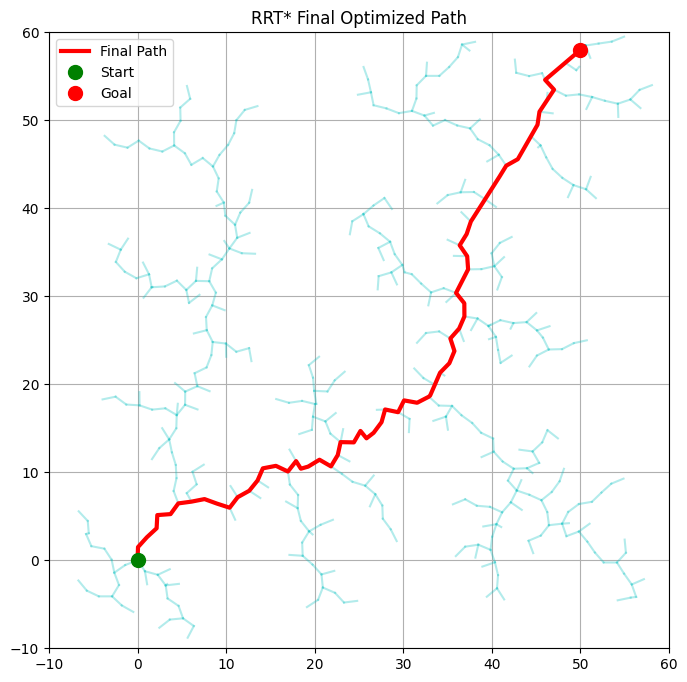

In [7]:
class RRTStar:
    # start and goal are tuples of (x,y) coordinates
    # area_size is a list of [x_min,x_max,y_min,y_max] defining the bounds of the search area
    # step_size is the maximum distance between nodes in the tree
    # search_radius is the radius within which to look for nearby nodes when rewiring 
    # max_iter is the maximum number of iterations to run the algorithm
    def __init__(self,start,goal,area_size,step_size=2.0,search_radius=10.0,max_iter=300):
        #convert the raw (x,y) into Node objects
        self.start=Node(start[0],start[1])
        self.goal=Node(goal[0],goal[1])

        #area_size format is[x_min,x_max,y_min,y_max]
        self.area_size=area_size

        #how far a new branch grows in one step
        self.step_size=step_size

        #how wide of a radius to look for neighbors during optimization
        self.search_radius=search_radius

        #how many random points to generate before giving up
        self.max_iter=max_iter

        #main list storing every single node in the tree
        self.node_list=[self.start]

    def get_random_node(self):
        #generate a random (x,y) within the area
        #10% of the time, cheat and return the goal to bias the search towards it
        if random.randint(0,100)>10:
            #generate a random float between min/max for x and y
            rnd=Node(random.uniform(self.area_size[0],self.area_size[1]),
                     random.uniform(self.area_size[2],self.area_size[3]))
            return rnd
        else:

            return Node(self.goal.x,self.goal.y)

    def get_nearest_node_index(self,rnd_node):
        #finds the index of the node in self.nodes that is closest to rnd_node

        #calculate the euclidean distance from rnd_node to every node in self.node_list
        #skip the square root for efficiency since we only care about relative distances
        dlist=[(node.x-rnd_node.x)**2+(node.y-rnd_node.y)**2 for node in self.node_list]

        #return the index of the smallest distance
        return dlist.index(min(dlist))
    
    def steer(self,from_node,to_node):
        #grows a branch from existing node toward the target node
        new_node=Node(from_node.x,from_node.y)
        
        #get the straight line distance and angle between the new nodes:
        d,theta=self.cal_dist_and_angle(new_node,to_node)

        #using trig to find new x and y exactly one step size away from from_node in the direction of to_node
        new_node.x+=self.step_size*math.cos(theta)
        new_node.y+=self.step_size*math.sin(theta)

        #update the cost and link back to the parent
        new_node.cost=from_node.cost+d
        new_node.parent=from_node
        return new_node
    
    def find_near_nodes(self,new_node):
        #finda all existing nodes within search_radius of new_node
        numnodes=len(self.node_list)

        #the radius shrinks slightly as the tre gets denser to keep math efficient
        #equation come from the paper, log(n)/n to prevent radius from shrinking too fast
        #search radiu is just a constant multiplier to adjust how much optimization is done
        r=self.search_radius*math.sqrt((math.log(numnodes)/numnodes))

        r=min(r,self.step_size)#cap the radius to the step size to prevent looking too far
        dist_list=[(node.x-new_node.x)**2+(node.y-new_node.y)**2 for node in self.node_list]
        #return the indices of nodes that are within the radius
        return [dist_list.index(i) for i in dist_list if i<=r**2]
    
    def choose_parent(self,new_node,near_inds):
        #evaluete nearby nodes and choose the one that results in the lowest cost to reach new_node

        #if there are no nearby nodes, just return the new node with its current parent and cost
        if not near_inds:
            return new_node
        
        cost=[]
        #calculate the theoretical cost if we connected through each nearby node
        for i in near_inds:
            near_node=self.node_list[i]
            d,_=self.cal_dist_and_angle(near_node,new_node)
            #add the cost from the start to each nearby node plus the cost to get from that node to the new node
            cost.append(near_node.cost+d)
        
        #find the neighbor that results in the lowest total cost to reach new_node
        min_cost=min(cost)
        min_ind=near_inds[cost.index(min_cost)]

        #assign the optimal neighbor as the parent of new_node and update its cost
        new_node.cost=min_cost
        new_node.parent=self.node_list[min_ind]
        return new_node
    
    def rewire(self,new_node,near_inds):
        #checks if neighbors can be reached more efficiently by going through new_node and updates their parent and cost if so
        for i in near_inds:
            near_node=self.node_list[i]
            d,_=self.cal_dist_and_angle(new_node,near_node)

            #scost is the theoretical cost of the neighbor if it went through new_node
            scost=new_node.cost+d

            #if routing through new_node is cheaper, update the neighbor to use new_node as its parent and update its cost
            if near_node.cost>scost:
                near_node.parent=new_node
                near_node.cost=scost
    
    def cal_dist_and_angle(self,node1,node2):
        #functions to calculte the distance and angle between two nodes
        dx=node2.x-node1.x
        dy=node2.y-node1.y
        d=math.hypot(dx,dy)
        theta=math.atan2(dy,dx)
        return d,theta
    
    def plan(self):
        #main execution loop and visualization
        for i in range(self.max_iter):

            #1.sample,find nearest,steer
            rnd_node=self.get_random_node()
            nearest_ind=self.get_nearest_node_index(rnd_node)
            nearest_node=self.node_list[nearest_ind]
            #steer from the nearest node towards the random node to get a new node
            new_node=self.steer(nearest_node,rnd_node)

            #2.optimize the new node by choosing the best parent from nearby nodes
            near_inds=self.find_near_nodes(new_node)
            new_node=self.choose_parent(new_node,near_inds)

            #add to the tree and optimize the tree by rewiring through the new node
            if new_node:
                self.node_list.append(new_node)
                self.rewire(new_node,near_inds)

            # --- VISUALIZATION LOGIC ---
            # We only draw the screen every 10 iterations to prevent Jupyter from crashing
            if i % 10 == 0:
                clear_output(wait=True) # Wipes the previous plot frame
                plt.figure(figsize=(8, 8))
                plt.axis(self.area_size)
                
                # Plot all the branches currently in the tree
                for node in self.node_list:
                    if node.parent: # If it has a parent, draw a line to it
                        plt.plot([node.parent.x, node.x], [node.parent.y, node.y], "-c", alpha=0.5)
                
                # Plot the start and goal dots on top
                plt.plot(self.start.x, self.start.y, "go", markersize=10, label="Start")
                plt.plot(self.goal.x, self.goal.y, "ro", markersize=10, label="Goal")
                
                plt.title(f"RRT* Expanding: Iteration {i}")
                plt.grid(True)
                plt.show()

            #-- Draw final optimized path--
            #find which node in our tree ended up closest to the goal
            dlist=[self.cal_dist_and_angle(node,self.goal)[0] for node in self.node_list]
            goal_ind=dlist.index(min(dlist))

            #trace the path back from the goal to the start using the parent pointers
            path_x,path_y=[],[]
            node=self.node_list[goal_ind]
            while node.parent is not None:
                path_x.append(node.x)
                path_y.append(node.y)
                node=node.parent
            
            #add the final start node to the path
            path_x.append(self.start.x)
            path_y.append(self.start.y)

            # Draw the final clean plot
        clear_output(wait=True)
        plt.figure(figsize=(8, 8))
        plt.axis(self.area_size)
        for node in self.node_list:
            if node.parent:
                plt.plot([node.parent.x, node.x], [node.parent.y, node.y], "-c", alpha=0.3)
        
        # Draw the traced path in a thick red line
        plt.plot(path_x, path_y, "-r", linewidth=3, label="Final Path")
        plt.plot(self.start.x, self.start.y, "go", markersize=10, label="Start")
        plt.plot(self.goal.x, self.goal.y, "ro", markersize=10, label="Goal")
        plt.title("RRT* Final Optimized Path")
        plt.legend()
        plt.grid(True)
        plt.show()

# Execution command to start the simulation
rrt_star = RRTStar(start=(0, 0), goal=(50, 58), area_size=[-10, 60, -10, 60],step_size=1.5, max_iter=500)
rrt_star.plan()
    